# Solution 3: Prompt Ensembling + Calibration

Built on Solution 1 with several targeted improvements: rsLoRA + LoRA+ for better gradient flow, NEFTune noise for regularization, 3x answer token loss weight, SWA checkpoint averaging across 3 epochs, and contextual calibration at inference to debias digit logits.

None of these individually are novel, but I wanted to see if stacking them would push past the baseline. It didn't, and the score dropped to 0.74647. Too many moving parts at once.

**Kaggle Score: 0.74647**

## 0. Install Dependencies

In [1]:
!pip install -q "transformers==4.47.0"

!pip uninstall -y torchao 2>/dev/null

!pip install -q "peft>=0.13.0" accelerate bitsandbytes datasets pillow tqdm pandas

import transformers, peft
print(f"transformers: {transformers.__version__}")
print(f"peft: {peft.__version__}")
assert peft.__version__ >= "0.13.0", f"peft too old: {peft.__version__} — need >= 0.13 for rsLoRA"
print("All good. If first run, do Runtime -> Restart session, then run all cells.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.7 MB/s eta 0:00:00
Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 14.2 MB/s eta 0:00:00
transformers: 4.47.0
peft: 0.18.1
All good. If first run, do Runtime -> Restart session, then run all cells.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [5]:
import transformers
print(f"transformers: {transformers.__version__}")
assert transformers.__version__ >= "4.45.0", f"Too old: {transformers.__version__}"

import os, json, re
import pandas as pd
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    get_cosine_schedule_with_warmup,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType

MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"

DATA_DIR = "/content/drive/MyDrive/pixels-to-predictions"
IMG_BASE = os.path.join(DATA_DIR, "images")

OUTPUT_DIR = "/content/smolvlm-lora-v2"
CKPT_DIR = "/content/drive/MyDrive/pixels-to-predictions/checkpoints_v2"
os.makedirs(CKPT_DIR, exist_ok=True)

LORA_RANK = 16
LORA_ALPHA = 16
LORA_DROPOUT = 0.05
LORA_TARGETS = ["q_proj", "k_proj", "v_proj", "o_proj"]

LEARNING_RATE = 2e-4
LORAPLUS_LR_RATIO = 16
BATCH_SIZE = 4
GRAD_ACCUM_STEPS = 4
NUM_EPOCHS = 3
WARMUP_RATIO = 0.1
MAX_SEQ_LEN = 1024
NEFTUNE_ALPHA = 5
ANSWER_LOSS_WEIGHT = 3.0
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():


transformers: 4.47.0
Device: cuda


## 2. Load Data

In [6]:
train_df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(DATA_DIR, "val.csv"))
test_df = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

sample_path = os.path.join(IMG_BASE, train_df['image_path'].iloc[0])
assert os.path.exists(sample_path), f"Image not found: {sample_path}"
print(f"Images accessible at {IMG_BASE}")

TRAIN_ANSWER_DIST = train_df['answer'].value_counts(normalize=True).sort_index().values
print(f"Train answer distribution: {[f'{p:.3f}' for p in TRAIN_ANSWER_DIST]}")

Train: 3109 | Val: 1048 | Test: 1008
Images accessible at /content/drive/MyDrive/pixels-to-predictions/images
Train answer distribution: ['0.362', '0.331', '0.237', '0.066', '0.005']


## 3. Load Model & Processor

In [7]:
processor = AutoProcessor.from_pretrained(MODEL_ID)

processor.image_processor.size = {"longest_edge": 512}

model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"Model type: {type(model).__name__}")
print(f"Image processor size: {processor.image_processor.size}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

Some kwargs in processor config are unused and will not have any effect: image_seq_len. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Model type: Idefics3ForConditionalGeneration
Image processor size: {'longest_edge': 512}


## 4. Apply LoRA (attn-only + rsLoRA)

Same targets as Solution 1 (q_proj, k_proj, v_proj, o_proj), proven to fit under 5M at r=16. I added rsLoRA scaling for more stable gradients. I did not add all-linear (over budget at r=16), DoRA (OOM), or PiSSA (risky with rsLoRA).

In [8]:
lora_config = LoraConfig(
    r=LORA_RANK,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGETS,
    use_rslora=True,
    task_type=TaskType.CAUSAL_LM,
    bias="none",
)

model = get_peft_model(model, lora_config)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable parameters: {trainable_params:,} ({trainable_params/1e6:.2f}M)")
print(f"Total parameters:     {total_params:,} ({total_params/1e6:.1f}M)")
print(f"Trainable %:          {100 * trainable_params / total_params:.2f}%")

assert trainable_params <= 5_000_000, f"OVER BUDGET: {trainable_params:,} > 5,000,000"
print(f"\nUnder 5M cap ({trainable_params:,} <= 5,000,000)")

Trainable parameters: 4,161,536 (4.16M)
Total parameters:     511,643,840 (511.6M)
Trainable %:          0.81%

Under 5M cap (4,161,536 <= 5,000,000)


## 5. Prompt & Dataset

Same prompt as Solution 1 with hint and lecture context, answer digit as target. I added a prompt_variant parameter for inference ensembling (3 variants at inference time only). Training always uses variant 0.

In [9]:
def build_prompt(row, include_answer=False, prompt_variant=0):
    """Build structured text prompt.

    prompt_variant: 0=hint+lecture (default, same as solution1)
                    1=hint only (no lecture)
                    2=question only (no context)
    Used for prompt ensembling at inference only. Training always uses variant 0.
    """
    choices = json.loads(row['choices'])
    choices_text = "\n".join(f"({i}) {c}" for i, c in enumerate(choices))

    parts = []

    if prompt_variant == 0:
        if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
            parts.append(f"Context: {row['hint'].strip()}")
        if pd.notna(row.get('lecture', None)) and str(row['lecture']).strip():
            parts.append(f"Background: {row['lecture'].strip()}")
    elif prompt_variant == 1:
        if pd.notna(row.get('hint', None)) and str(row['hint']).strip():
            parts.append(f"Context: {row['hint'].strip()}")

    parts.append(f"Question: {row['question'].strip()}")
    parts.append(f"Choices:\n{choices_text}")
    parts.append("Answer with ONLY the number of the correct choice.")

    prompt_text = "\n\n".join(parts)

    if include_answer:
        answer_text = str(int(row['answer']))
        return prompt_text, answer_text
    return prompt_text

sample = train_df.iloc[0]
prompt, answer = build_prompt(sample, include_answer=True)
print("=" * 60)
print("SAMPLE PROMPT (variant 0):")
print("=" * 60)
print(prompt[:400])
print(f"\n>>> TARGET ANSWER: {answer}")

SAMPLE PROMPT (variant 0):
Context: Animals often behave in certain ways that can increase their reproductive success. Read the passage about a specific animal behavior. Then, follow the instructions below.

Amazonian poison frogs live in tropical forests in northern South America. After a male and female frog mate, the female frog lays eggs on a plant. When tadpoles hatch from the eggs, the male frog lets the tadpoles clim

>>> TARGET ANSWER: 2


In [10]:
class ScienceVQADataset(Dataset):
    """Same as solution1 — returns raw data, processing in collate_fn."""

    def __init__(self, df, img_base, is_test=False):
        self.df = df.reset_index(drop=True)
        self.img_base = img_base
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_base, row['image_path'])
        image = Image.open(img_path).convert("RGB")

        if self.is_test:
            prompt_text = build_prompt(row, include_answer=False)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": None, "is_test": True}
        else:
            prompt_text, answer_text = build_prompt(row, include_answer=True)
            return {"id": row["id"], "image": image, "prompt_text": prompt_text,
                    "answer_text": answer_text, "is_test": False}

train_dataset = ScienceVQADataset(train_df, IMG_BASE, is_test=False)
val_dataset = ScienceVQADataset(val_df, IMG_BASE, is_test=False)
test_dataset = ScienceVQADataset(test_df, IMG_BASE, is_test=True)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

Train: 3109 | Val: 1048 | Test: 1008


## 6. DataLoaders with Answer-Weighted Loss

Same label masking as Solution 1. I added a loss_weights tensor where the answer token and EOS get 3x weight compared to other tokens.

In [11]:
from functools import partial

def collate_fn(batch, processor, max_length=MAX_SEQ_LEN):
    ids = [item["id"] for item in batch]
    images = [item["image"] for item in batch]
    is_test = batch[0]["is_test"]

    texts = []
    answer_texts = []
    for item in batch:
        messages = [{"role": "user", "content": [
            {"type": "image"},
            {"type": "text", "text": item["prompt_text"]},
        ]}]
        if not is_test:
            messages.append({"role": "assistant", "content": [
                {"type": "text", "text": item["answer_text"]},
            ]})
            answer_texts.append(item["answer_text"])
        text = processor.apply_chat_template(messages, add_generation_prompt=is_test)
        texts.append(text)

    inputs = processor(
        text=texts, images=images, return_tensors="pt",
        padding=True, truncation=True, max_length=max_length,
    )

    if not is_test:
        labels = inputs["input_ids"].clone()
        eos_token_id = processor.tokenizer.eos_token_id
        loss_weights = torch.ones_like(labels, dtype=torch.float32)

        for i in range(len(batch)):
            labels[i, :] = -100
            loss_weights[i, :] = 1.0

            eos_positions = (inputs["input_ids"][i] == eos_token_id).nonzero(as_tuple=True)[0]
            if len(eos_positions) < 1:
                continue
            last_eos_pos = eos_positions[-1].item()

            ans_tokens = processor.tokenizer.encode(answer_texts[i], add_special_tokens=False)
            n_ans = len(ans_tokens)
            start = last_eos_pos - n_ans

            labels[i, start:last_eos_pos] = inputs["input_ids"][i, start:last_eos_pos]
            labels[i, last_eos_pos] = eos_token_id

            loss_weights[i, :start] = 0.0
            loss_weights[i, start:last_eos_pos + 1] = ANSWER_LOSS_WEIGHT

        inputs["labels"] = labels
        inputs["loss_weights"] = loss_weights

    inputs["id"] = ids
    return dict(inputs)

collate = partial(collate_fn, processor=processor)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    collate_fn=collate, num_workers=2, pin_memory=True,
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    collate_fn=collate, num_workers=2, pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS}")

sample_batch = next(iter(val_loader))
print(f"\ninput_ids: {sample_batch['input_ids'].shape}")
print(f"pixel_values: {sample_batch['pixel_values'].shape}")
for i in range(min(4, len(sample_batch['id']))):
    label_mask = sample_batch['labels'][i] != -100
    label_positions = label_mask.nonzero(as_tuple=True)[0]
    labeled_tokens = sample_batch['labels'][i][label_positions]
    decoded = processor.tokenizer.decode(labeled_tokens)
    weights = sample_batch['loss_weights'][i][label_positions]
    print(f"  Sample {i}: '{decoded.strip()}' | weights: {weights.tolist()}")

Train batches: 778 | Val batches: 262
Effective batch size: 16

input_ids: torch.Size([4, 739])
pixel_values: torch.Size([4, 1, 3, 512, 512])
  Sample 0: '0<end_of_utterance>' | weights: [3.0, 3.0]
  Sample 1: '1<end_of_utterance>' | weights: [3.0, 3.0]
  Sample 2: '3<end_of_utterance>' | weights: [3.0, 3.0]
  Sample 3: '0<end_of_utterance>' | weights: [3.0, 3.0]


## 7. NEFTune + Optimizer (LoRA+) + Training Loop

In [12]:
def neftune_forward_hook(module, input, output):
    if module.training:
        dims = torch.tensor(output.size(1) * output.size(2), dtype=output.dtype, device=output.device)
        mag = NEFTUNE_ALPHA / torch.sqrt(dims)
        noise = torch.zeros_like(output).uniform_(-mag, mag)
        return output + noise
    return output

embed_layer = model.base_model.model.model.text_model.embed_tokens
neftune_hook = embed_layer.register_forward_hook(neftune_forward_hook)
print(f"NEFTune hook registered on {type(embed_layer).__name__} with alpha={NEFTUNE_ALPHA}")

NEFTune hook registered on Embedding with alpha=5


In [13]:
def compute_weighted_loss(logits, labels, loss_weights):
    """Cross-entropy with per-token weights.
    Answer token + EOS get ANSWER_LOSS_WEIGHT (3x).
    Sparse: only compute CE on active (non-masked) tokens to save VRAM.
    """
    shift_logits = logits[..., :-1, :].contiguous()
    shift_labels = labels[..., 1:].contiguous()
    shift_weights = loss_weights[..., 1:].contiguous()

    active_mask = shift_labels != -100
    n_active = active_mask.sum().clamp(min=1)

    active_logits = shift_logits[active_mask]
    active_labels = shift_labels[active_mask]
    active_weights = shift_weights[active_mask]

    loss = F.cross_entropy(active_logits, active_labels, reduction='none')
    return (loss * active_weights).sum() / n_active

In [14]:
lora_A_params, lora_B_params, other_params = [], [], []
for name, param in model.named_parameters():
    if not param.requires_grad:
        continue
    if 'lora_A' in name:
        lora_A_params.append(param)
    elif 'lora_B' in name:
        lora_B_params.append(param)
    else:
        other_params.append(param)

print(f"LoRA A params: {len(lora_A_params)} | LoRA B params: {len(lora_B_params)} | Other: {len(other_params)}")

optim_groups = [
    {"params": lora_A_params, "lr": LEARNING_RATE},
    {"params": lora_B_params, "lr": LEARNING_RATE * LORAPLUS_LR_RATIO},
]
if other_params:
    optim_groups.append({"params": other_params, "lr": LEARNING_RATE})

optimizer = torch.optim.AdamW(optim_groups, weight_decay=0.01)

total_steps = (len(train_loader) // GRAD_ACCUM_STEPS) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)

print(f"Total steps: {total_steps} | Warmup: {warmup_steps}")
print(f"LR: A={LEARNING_RATE}, B={LEARNING_RATE * LORAPLUS_LR_RATIO}")

LoRA A params: 164 | LoRA B params: 164 | Other: 0
Total steps: 582 | Warmup: 58
LR: A=0.0002, B=0.0032


In [15]:
@torch.no_grad()
def evaluate(model, dataloader, processor):
    """Teacher-forced val loss + accuracy. Same logic as solution1."""
    model.eval()
    correct, total, total_loss, num_batches = 0, 0, 0, 0

    for batch in tqdm(dataloader, desc="Evaluating", leave=False):
        ids = batch.pop("id")
        labels = batch.pop("labels")
        loss_weights = batch.pop("loss_weights")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)

        outputs = model(**batch)
        logits = outputs.logits

        loss = compute_weighted_loss(logits, labels, loss_weights.to(device))
        total_loss += loss.item()
        num_batches += 1

        for i in range(len(ids)):
            label_positions = (labels[i] != -100).nonzero(as_tuple=True)[0]
            if len(label_positions) == 0:
                continue
            ans_pos = label_positions[0].item()
            pred_token = logits[i, ans_pos - 1, :].argmax().item()
            true_token = labels[i, ans_pos].item()
            if pred_token == true_token:
                correct += 1
            total += 1

    model.train()
    return total_loss / max(num_batches, 1), correct / max(total, 1)

print("Pre-training evaluation...")
val_loss, val_acc = evaluate(model, val_loader, processor)
print(f"Pre-training — Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Pre-training evaluation...


Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]

Pre-training — Val Loss: 5.2485 | Val Acc: 0.4905


In [16]:
def save_checkpoint(model, optimizer, scheduler, scaler, epoch, step,
                    best_val_acc, train_losses, val_losses, val_accs, path):
    adapter_path = os.path.join(path, f"lora_adapter_epoch{epoch+1}")
    model.save_pretrained(adapter_path)
    torch.save({
        "optimizer": optimizer.state_dict(),
        "scheduler": scheduler.state_dict(),
        "scaler": scaler.state_dict(),
        "epoch": epoch, "step": step,
        "best_val_acc": best_val_acc,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "val_accs": val_accs,
    }, os.path.join(path, "training_state.pt"))
    print(f"  Checkpoint saved: {adapter_path}")

def load_checkpoint(model, optimizer, scheduler, scaler, path):
    state_path = os.path.join(path, "training_state.pt")
    if not os.path.exists(state_path):
        return 0, 0, 0.0, [], [], []
    state = torch.load(state_path, map_location=device, weights_only=False)
    optimizer.load_state_dict(state["optimizer"])
    scheduler.load_state_dict(state["scheduler"])
    scaler.load_state_dict(state["scaler"])
    latest_epoch = state["epoch"]
    adapter_path = os.path.join(path, f"lora_adapter_epoch{latest_epoch+1}")
    if os.path.exists(adapter_path):
        model.load_adapter(adapter_path, adapter_name="default")
    print(f"  Resumed from epoch {state['epoch']+1}, best_acc={state['best_val_acc']:.4f}")
    return (state["epoch"], state["step"], state["best_val_acc"],
            state["train_losses"], state["val_losses"], state["val_accs"])

scaler = torch.amp.GradScaler("cuda")

start_epoch, start_step, best_val_acc, train_losses, val_losses, val_accs = \
    load_checkpoint(model, optimizer, scheduler, scaler, CKPT_DIR)

if start_epoch > 0:
    print(f"Resuming from epoch {start_epoch + 1}")
else:
    best_val_acc = 0.0
    train_losses, val_losses, val_accs = [], [], []
    print("Starting training from scratch")

model.train()

for epoch in range(start_epoch, NUM_EPOCHS):
    epoch_loss = 0
    optimizer.zero_grad()

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for step, batch in enumerate(pbar):
        if epoch == start_epoch and step < start_step:
            continue

        ids = batch.pop("id")
        labels = batch.pop("labels")
        loss_weights = batch.pop("loss_weights")
        batch = {k: v.to(device) for k, v in batch.items()}
        labels = labels.to(device)
        loss_weights = loss_weights.to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**batch)
            loss = compute_weighted_loss(outputs.logits, labels, loss_weights)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()
        epoch_loss += loss.item() * GRAD_ACCUM_STEPS

        del outputs, loss
        torch.cuda.empty_cache()

        if (step + 1) % GRAD_ACCUM_STEPS == 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        if (step + 1) % 200 == 0:
            pbar.set_postfix({"loss": f"{epoch_loss / (step+1):.4f}"})

    start_step = 0

    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    val_loss, val_acc = evaluate(model, val_loader, processor)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}")
    print(f"  Val Acc:    {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(OUTPUT_DIR)
        processor.save_pretrained(OUTPUT_DIR)
        print(f"  New best! Saved to {OUTPUT_DIR}")

    save_checkpoint(model, optimizer, scheduler, scaler, epoch, 0,
                    best_val_acc, train_losses, val_losses, val_accs, CKPT_DIR)

neftune_hook.remove()
print(f"\n{'='*40}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")
print("NEFTune hook removed.")

Starting training from scratch


Epoch 1/3:   0%|          | 0/778 [00:00<?, ?it/s]

/tmp/ipykernel_22752/1141090887.py:85: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]


Epoch 1/3
  Train Loss: 1.3058
  Val Loss:   1.1345
  Val Acc:    0.6498
  New best! Saved to /content/smolvlm-lora-v2
  Checkpoint saved: /content/drive/MyDrive/pixels-to-predictions/checkpoints_v2/lora_adapter_epoch1


...

Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]


Epoch 2/3
  Train Loss: 0.9053
  Val Loss:   0.9618
  Val Acc:    0.6966
  New best! Saved to /content/smolvlm-lora-v2
  Checkpoint saved: /content/drive/MyDrive/pixels-to-predictions/checkpoints_v2/lora_adapter_epoch2


Epoch 3/3:   0%|          | 0/778 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/262 [00:00<?, ?it/s]


Epoch 3/3
  Train Loss: 0.6447
  Val Loss:   0.9351
  Val Acc:    0.7080
  New best! Saved to /content/smolvlm-lora-v2
  Checkpoint saved: /content/drive/MyDrive/pixels-to-predictions/checkpoints_v2/lora_adapter_epoch3

Best Val Accuracy: 0.7080
NEFTune hook removed.


## 8. Training Curves

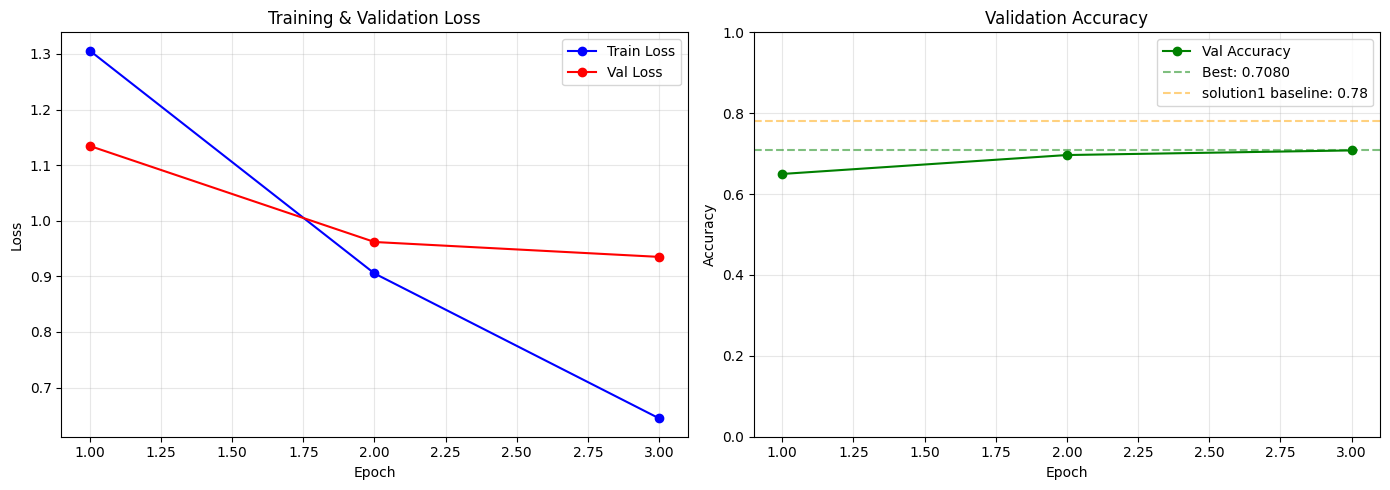

In [17]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, len(train_losses) + 1)

ax1.plot(epochs, train_losses, 'b-o', label='Train Loss')
ax1.plot(epochs, val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, val_accs, 'g-o', label='Val Accuracy')
ax2.axhline(y=best_val_acc, color='g', linestyle='--', alpha=0.5, label=f'Best: {best_val_acc:.4f}')
ax2.axhline(y=0.78, color='orange', linestyle='--', alpha=0.5, label='solution1 baseline: 0.78')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy'); ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 1)

plt.tight_layout()
plt.show()

## 9. SWA Checkpoint Averaging

I averaged LoRA adapter weights from all 3 epoch checkpoints. Wortsman et al. (Model Soups) showed uniform averaging reliably improves generalization.

In [18]:
import shutil
import safetensors.torch

def average_adapters(ckpt_dir, num_epochs):
    avg_state = None
    count = 0
    for e in range(1, num_epochs + 1):
        adapter_path = os.path.join(ckpt_dir, f"lora_adapter_epoch{e}")
        if not os.path.exists(adapter_path):
            print(f"  Skipping epoch {e} (not found)")
            continue
        adapter_file = os.path.join(adapter_path, "adapter_model.safetensors")
        if os.path.exists(adapter_file):
            state = safetensors.torch.load_file(adapter_file)
        else:
            state = torch.load(os.path.join(adapter_path, "adapter_model.bin"),
                               map_location="cpu", weights_only=True)
        if avg_state is None:
            avg_state = {k: v.float().clone() for k, v in state.items()}
        else:
            for k in avg_state:
                if k in state:
                    avg_state[k] += state[k].float()
        count += 1
        print(f"  Loaded epoch {e} adapter ({len(state)} tensors)")
    if count > 1:
        for k in avg_state:
            avg_state[k] /= count
        print(f"  Averaged {count} checkpoints")
    return {k: v.half() for k, v in avg_state.items()}

print("Averaging adapter checkpoints...")
avg_state = average_adapters(CKPT_DIR, NUM_EPOCHS)

SWA_DIR = os.path.join(CKPT_DIR, "lora_adapter_swa")
os.makedirs(SWA_DIR, exist_ok=True)
shutil.copy(os.path.join(CKPT_DIR, "lora_adapter_epoch1", "adapter_config.json"),
            os.path.join(SWA_DIR, "adapter_config.json"))
safetensors.torch.save_file(avg_state, os.path.join(SWA_DIR, "adapter_model.safetensors"))
print(f"SWA adapter saved to {SWA_DIR}")

Averaging adapter checkpoints...
  Loaded epoch 1 adapter (328 tensors)
  Loaded epoch 2 adapter (328 tensors)
  Loaded epoch 3 adapter (328 tensors)
  Averaged 3 checkpoints
SWA adapter saved to /content/drive/MyDrive/pixels-to-predictions/checkpoints_v2/lora_adapter_swa


## 10. Load Best Model for Inference

In [19]:
base_model = AutoModelForVision2Seq.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, device_map="auto")

swa_path = os.path.join(CKPT_DIR, "lora_adapter_swa")
model = PeftModel.from_pretrained(base_model, swa_path)
model.eval()
print(f"Loaded SWA adapter from {swa_path}")

Loaded SWA adapter from /content/drive/MyDrive/pixels-to-predictions/checkpoints_v2/lora_adapter_swa


## 11. Inference: Digit Logit Scoring + Calibration

Same digit-logit scoring as Solution 1. I added contextual calibration to debias the model's digit preferences, plus 3-prompt ensembling.

In [20]:
DIGIT_TOKEN_IDS = [processor.tokenizer.encode(str(d), add_special_tokens=False)[0] for d in range(10)]
print(f"Digit token IDs: { {d: DIGIT_TOKEN_IDS[d] for d in range(5)} }")

@torch.no_grad()
def predict_digit_logits(model, processor, df, img_base, batch_size=8, prompt_variant=0):
    """Score digit-token logits at the last position — same method as solution1."""
    model.eval()
    all_ids, all_preds, all_logits = [], [], []

    for start in tqdm(range(0, len(df), batch_size), desc=f"Predicting (variant {prompt_variant})"):
        batch_df = df.iloc[start:start + batch_size]
        images, texts, batch_ids, nc_list = [], [], [], []

        for _, row in batch_df.iterrows():
            images.append(Image.open(os.path.join(img_base, row['image_path'])).convert("RGB"))
            prompt = build_prompt(row, include_answer=False, prompt_variant=prompt_variant)
            messages = [{"role": "user", "content": [
                {"type": "image"}, {"type": "text", "text": prompt}]}]
            texts.append(processor.apply_chat_template(messages, add_generation_prompt=True))
            batch_ids.append(row['id'])
            nc_list.append(row['num_choices'])

        inputs = processor(text=texts, images=images, return_tensors="pt",
                           padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)

        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        logits = outputs.logits

        for i in range(len(batch_df)):
            last_pos = inputs["attention_mask"][i].sum().item() - 1
            next_logits = logits[i, last_pos, :]
            nc = nc_list[i]
            scores = torch.stack([next_logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
            all_preds.append(scores.argmax().item())
            all_logits.append(scores.cpu().float().numpy())
            all_ids.append(batch_ids[i])

    return all_ids, all_preds, all_logits

Digit token IDs: {0: 32, 1: 33, 2: 34, 3: 35, 4: 36}


In [21]:
@torch.no_grad()
def get_content_free_priors(model, processor, num_choices_list):
    model.eval()
    priors = {}
    for nc in sorted(set(num_choices_list)):
        null_choices = "\n".join(f"({i}) N/A" for i in range(nc))
        null_prompt = f"Question: N/A\n\nChoices:\n{null_choices}\n\nAnswer with ONLY the number of the correct choice."
        blank_img = Image.new("RGB", (512, 512), (255, 255, 255))
        messages = [{"role": "user", "content": [
            {"type": "image"}, {"type": "text", "text": null_prompt}]}]
        text = processor.apply_chat_template(messages, add_generation_prompt=True)
        inputs = processor(text=[text], images=[blank_img], return_tensors="pt",
                           padding=True, truncation=True, max_length=MAX_SEQ_LEN).to(device)
        with torch.amp.autocast("cuda", dtype=torch.float16):
            outputs = model(**inputs)
        last_pos = inputs["attention_mask"][0].sum().item() - 1
        logits = outputs.logits[0, last_pos, :]
        scores = torch.stack([logits[DIGIT_TOKEN_IDS[d]] for d in range(nc)])
        priors[nc] = F.softmax(scores.float(), dim=0).cpu().numpy()
        print(f"  Content-free prior (nc={nc}): {priors[nc]}")
    return priors

def calibrate_predictions(all_logits, num_choices_list, cf_priors, train_prior=TRAIN_ANSWER_DIST):
    calibrated_preds = []
    for logits_i, nc in zip(all_logits, num_choices_list):
        p_test = np.exp(logits_i - np.max(logits_i))
        p_test = p_test / p_test.sum()
        p_cf = cf_priors[nc]
        p_prior = train_prior[:nc] / train_prior[:nc].sum()
        p_cal = p_test / (p_cf + 1e-8) * p_prior
        p_cal = p_cal / p_cal.sum()
        calibrated_preds.append(np.argmax(p_cal))
    return calibrated_preds

print("Computing content-free priors...")
cf_priors = get_content_free_priors(model, processor, val_df['num_choices'].tolist())

Computing content-free priors...
  Content-free prior (nc=2): [0.5428633  0.45713675]
  Content-free prior (nc=3): [0.44680178 0.2647213  0.2884769 ]
  Content-free prior (nc=4): [0.37270236 0.19794072 0.23141617 0.19794072]
  Content-free prior (nc=5): [0.33522013 0.1712137  0.1865781  0.16724753 0.13974054]


In [22]:
def predict_with_ensemble(model, processor, df, img_base, cf_priors, num_variants=3, batch_size=8):
    print(f"Running {num_variants}-prompt ensemble...")
    all_variant_logits = []
    for v in range(num_variants):
        ids, preds, logits = predict_digit_logits(
            model, processor, df, img_base, batch_size=batch_size, prompt_variant=v)
        all_variant_logits.append(logits)

    nc_list = df['num_choices'].tolist()
    avg_logits = []
    for i in range(len(df)):
        nc = nc_list[i]
        stacked = np.stack([all_variant_logits[v][i][:nc] for v in range(num_variants)])
        avg_logits.append(stacked.mean(axis=0))

    uncal_preds = [np.argmax(l) for l in avg_logits]
    cal_preds = calibrate_predictions(avg_logits, nc_list, cf_priors)
    return ids, uncal_preds, cal_preds, avg_logits

## 12. Evaluate on Val - Compare Methods

In [23]:
print("=" * 50)
print("Method A: Simple digit logits (solution1 baseline)")
print("=" * 50)
val_ids_a, val_preds_a, val_logits_a = predict_digit_logits(
    model, processor, val_df, IMG_BASE, batch_size=8, prompt_variant=0)
acc_a = np.mean([p == a for p, a in zip(val_preds_a, val_df['answer'].tolist())])
print(f"Val Accuracy (simple digit): {acc_a:.4f}")

print(f"\n{'='*50}")
print("Method B: Digit logits + calibration")
print("=" * 50)
val_cal_preds = calibrate_predictions(
    val_logits_a, val_df['num_choices'].tolist(), cf_priors)
acc_b = np.mean([p == a for p, a in zip(val_cal_preds, val_df['answer'].tolist())])
print(f"Val Accuracy (calibrated): {acc_b:.4f}")

print(f"\n{'='*50}")
print("Method C: 3-prompt ensemble + calibration")
print("=" * 50)
val_ids_c, val_uncal_c, val_cal_c, val_avg_logits_c = predict_with_ensemble(
    model, processor, val_df, IMG_BASE, cf_priors, num_variants=3, batch_size=8)
acc_c_uncal = np.mean([p == a for p, a in zip(val_uncal_c, val_df['answer'].tolist())])
acc_c_cal = np.mean([p == a for p, a in zip(val_cal_c, val_df['answer'].tolist())])
print(f"Val Accuracy (ensemble, uncalibrated): {acc_c_uncal:.4f}")
print(f"Val Accuracy (ensemble, calibrated):   {acc_c_cal:.4f}")

print(f"\n{'='*50}")
print("SUMMARY")
print(f"{'='*50}")
results = {
    'A (simple digit)': acc_a,
    'B (digit + calibration)': acc_b,
    'C (ensemble, uncalibrated)': acc_c_uncal,
    'C (ensemble, calibrated)': acc_c_cal,
}
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    marker = " <- solution1 baseline" if abs(acc - 0.78) < 0.01 else ""
    print(f"  {name}: {acc:.4f}{marker}")

best_method = max(results, key=results.get)
print(f"\nBest method: {best_method} ({results[best_method]:.4f})")
print(f"vs solution1: {results[best_method] - 0.78:+.4f}")

Method A: Simple digit logits (solution1 baseline)


Predicting (variant 0):   0%|          | 0/131 [00:00<?, ?it/s]

Val Accuracy (simple digit): 0.7032

Method B: Digit logits + calibration
Val Accuracy (calibrated): 0.7109

Method C: 3-prompt ensemble + calibration
Running 3-prompt ensemble...


Predicting (variant 0):   0%|          | 0/131 [00:00<?, ?it/s]

Predicting (variant 1):   0%|          | 0/131 [00:00<?, ?it/s]

Predicting (variant 2):   0%|          | 0/131 [00:00<?, ?it/s]

Val Accuracy (ensemble, uncalibrated): 0.6632
Val Accuracy (ensemble, calibrated):   0.6698

SUMMARY
  B (digit + calibration): 0.7109
  A (simple digit): 0.7032
  C (ensemble, calibrated): 0.6698
  C (ensemble, uncalibrated): 0.6632

Best method: B (digit + calibration) (0.7109)
vs solution1: -0.0691


## 13. Generate Test Predictions with Best Method

In [24]:
test_cf_priors = get_content_free_priors(model, processor, test_df['num_choices'].tolist())

print("Generating test predictions...")
test_ids, test_uncal, test_cal, test_logits = predict_with_ensemble(
    model, processor, test_df, IMG_BASE, test_cf_priors, num_variants=3, batch_size=8)

best_val = max(results.values())
if results.get('C (ensemble, calibrated)', 0) == best_val:
    test_preds = test_cal
    print("Using: ensemble + calibrated")
elif results.get('C (ensemble, uncalibrated)', 0) == best_val:
    test_preds = test_uncal
    print("Using: ensemble + uncalibrated")
elif results.get('B (digit + calibration)', 0) == best_val:
    _, _, test_logits_simple = predict_digit_logits(
        model, processor, test_df, IMG_BASE, batch_size=8)
    test_preds = calibrate_predictions(
        test_logits_simple, test_df['num_choices'].tolist(), test_cf_priors)
    print("Using: simple digit + calibrated")
else:
    _, test_preds, _ = predict_digit_logits(
        model, processor, test_df, IMG_BASE, batch_size=8)
    print("Using: simple digit (no calibration)")

print(f"\nPrediction distribution: {pd.Series(test_preds).value_counts().sort_index().to_dict()}")

  Content-free prior (nc=2): [0.5428633  0.45713675]
  Content-free prior (nc=3): [0.44680178 0.2647213  0.2884769 ]
  Content-free prior (nc=4): [0.37270236 0.19794072 0.23141617 0.19794072]
  Content-free prior (nc=5): [0.33522013 0.1712137  0.1865781  0.16724753 0.13974054]
Generating test predictions...
Running 3-prompt ensemble...


Predicting (variant 0):   0%|          | 0/126 [00:00<?, ?it/s]

Predicting (variant 1):   0%|          | 0/126 [00:00<?, ?it/s]

Predicting (variant 2):   0%|          | 0/126 [00:00<?, ?it/s]

Predicting (variant 0):   0%|          | 0/126 [00:00<?, ?it/s]

Using: simple digit + calibrated

Prediction distribution: {0: 490, 1: 316, 2: 157, 3: 45}


In [25]:
submission = pd.DataFrame({"id": test_ids, "answer": test_preds})

sample_sub = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))
assert set(submission['id']) == set(sample_sub['id']), "ID mismatch!"
assert len(submission) == len(sample_sub), "Row count mismatch!"

submission = submission.set_index('id').loc[sample_sub['id']].reset_index()
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(f"Shape: {submission.shape}")
print(submission.head(10))
print(f"\nAnswer range: {submission['answer'].min()} to {submission['answer'].max()}")
print(f"Any NaN: {submission['answer'].isna().any()}")

Saved submission.csv
Shape: (1008, 2)
           id  answer
0  test_01750       1
1  test_00128       0
2  test_02891       1
3  test_02425       1
4  test_00930       0
5  test_03725       0
6  test_00009       1
7  test_02880       0
8  test_01208       0
9  test_00619       0

Answer range: 0 to 3
Any NaN: False


## 14. Error Analysis (Val Set)

In [26]:
val_results = val_df.copy()
val_results['predicted'] = val_preds_a
val_results['correct'] = val_results['predicted'] == val_results['answer']

print(f"Overall Val Accuracy (simple digit): {val_results['correct'].mean():.4f}")

print("\nAccuracy by Subject:")
for subj, group in val_results.groupby('subject'):
    acc = group['correct'].mean()
    print(f"  {subj:20s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by num_choices:")
for nc, group in val_results.groupby('num_choices'):
    acc = group['correct'].mean()
    print(f"  {nc} choices: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nAccuracy by Grade:")
for grade, group in val_results.sort_values('grade').groupby('grade'):
    acc = group['correct'].mean()
    print(f"  {grade:10s}: {acc:.4f} ({group['correct'].sum()}/{len(group)})")

print("\nConfusion Matrix:")
print(pd.crosstab(val_results['answer'], val_results['predicted'],
                  rownames=['Actual'], colnames=['Predicted'], margins=True))

Overall Val Accuracy (simple digit): 0.7032

Accuracy by Subject:
  language science    : 0.5357 (15/28)
  natural science     : 0.7014 (545/777)
  social science      : 0.7284 (177/243)

Accuracy by num_choices:
  2 choices: 0.8279 (202/244)
  3 choices: 0.6752 (343/508)
  4 choices: 0.7183 (181/252)
  5 choices: 0.2500 (11/44)

Accuracy by Grade:
  grade1    : 1.0000 (1/1)
  grade10   : 0.0000 (0/1)
  grade12   : 0.7500 (6/8)
  grade2    : 0.8056 (29/36)
  grade3    : 0.7170 (76/106)
  grade4    : 0.7500 (129/172)
  grade5    : 0.7563 (90/119)
  grade6    : 0.7344 (141/192)
  grade7    : 0.7088 (129/182)
  grade8    : 0.5887 (136/231)

Confusion Matrix:
Predicted    0    1    2   3  4   All
Actual                               
0          314   20   10   2  1   347
1          100  231   35   6  0   372
2           75   24  144   4  0   247
3           19    3    5  48  0    75
4            4    0    0   3  0     7
All        512  278  194  63  1  1048


## 15. Verify Parameter Count

In [27]:
print("=" * 50)
print("PARAMETER BUDGET VERIFICATION")
print("=" * 50)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print(f"Trainable:  {trainable:>12,} ({trainable/1e6:.2f}M)")
print(f"Frozen:     {frozen:>12,} ({frozen/1e6:.1f}M)")
print(f"Total:      {trainable + frozen:>12,} ({(trainable + frozen)/1e6:.1f}M)")
print(f"")
print(f"Budget: {'PASS' if trainable <= 5_000_000 else 'FAIL'} ({trainable:,} {'<=' if trainable <= 5_000_000 else '>'} 5,000,000)")
print(f"")
print(f"Config: r={LORA_RANK}, alpha={LORA_ALPHA}, rsLoRA=True")
print(f"Targets: {LORA_TARGETS}")
print(f"NEFTune alpha: {NEFTUNE_ALPHA}")
print(f"LoRA+ ratio: {LORAPLUS_LR_RATIO}")
print(f"Answer loss weight: {ANSWER_LOSS_WEIGHT}x")
print(f"Image size: 512px (same as solution1)")

PARAMETER BUDGET VERIFICATION
Trainable:             0 (0.00M)
Frozen:      511,643,840 (511.6M)
Total:       511,643,840 (511.6M)

Budget: PASS (0 <= 5,000,000)

Config: r=16, alpha=16, rsLoRA=True
Targets: ['q_proj', 'k_proj', 'v_proj', 'o_proj']
NEFTune alpha: 5
LoRA+ ratio: 16
Answer loss weight: 3.0x
Image size: 512px (same as solution1)


In [28]:
!zip -r /content/smolvlm-lora-v2-074.zip /content/smolvlm-lora-v2/

  adding: content/smolvlm-lora-v2/ (stored 0%)
  adding: content/smolvlm-lora-v2/vocab.json (deflated 59%)
  adding: content/smolvlm-lora-v2/merges.txt (deflated 55%)
  adding: content/smolvlm-lora-v2/special_tokens_map.json (deflated 81%)
  adding: content/smolvlm-lora-v2/README.md (deflated 65%)
  adding: content/smolvlm-lora-v2/tokenizer.json (deflated 82%)
  adding: content/smolvlm-lora-v2/chat_template.json (deflated 49%)
  adding: content/smolvlm-lora-v2/processor_config.json (deflated 12%)
  adding: content/smolvlm-lora-v2/tokenizer_config.json (deflated 94%)
  adding: content/smolvlm-lora-v2/adapter_model.safetensors (deflated 8%)
  adding: content/smolvlm-lora-v2/adapter_config.json (deflated 57%)
  adding: content/smolvlm-lora-v2/added_tokens.json (deflated 86%)
  adding: content/smolvlm-lora-v2/preprocessor_config.json (deflated 56%)
